# CISC3024 - Pattern Recognition Project
## Handwritten Digit Generation Using Diffusion Models
### DC229292 CHENXINGCHEN

**Project Overview:**
This project implements a diffusion model for generating handwritten digits using the MNIST dataset. The model is built with PyTorch and Diffusers library, incorporating classifier-free guidance for conditional generation.

**Key Features:**
- Diffusion model training on MNIST dataset
- Classifier-free guidance for conditional generation
- Inception Score and FID evaluation
- Visualization of generated samples

In [26]:
# 导入必要的库
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
from diffusers import UNet2DModel, DDPMScheduler
from torchvision.models import inception_v3
from scipy import linalg
import pandas as pd
from PIL import Image

# 设置随机种子以确保可重复性
torch.manual_seed(42)
np.random.seed(42)

In [27]:
# 配置类
class Config:
    image_size = 32  # 图像大小 32x32
    batch_size_train = 32  # 训练批量大小
    batch_size_eval = 32  # 评估批量大小
    num_epochs = 5  # 训练循环次数
    learning_rate = 1e-4  # 学习率
    num_classes = 10  # 生成的数字类别 0-9
    time_steps = 1000  # 时间步
    cfg_scale = 7.5  # 分类器自由引导值
    channels = 1  # 添加通道数参数（灰度图）
    output_dir = "output"  # 添加输出目录
    save_model_epochs = 2  # 添加模型保存频率

    def __str__(self):
        return f"""配置参数:
        - 图像大小: {self.image_size}x{self.image_size}
        - 训练批量大小: {self.batch_size_train}
        - 评估批量大小: {self.batch_size_eval}
        - 训练轮数: {self.num_epochs}
        - 学习率: {self.learning_rate}
        - 数字类别: 0-{self.num_classes-1}
        - 时间步: {self.time_steps}
        - CFG尺度: {self.cfg_scale}
        - 通道数: {self.channels}"""

# 创建配置实例
config = Config()

### Configuration Parameters
The project uses a centralized configuration class to manage all hyperparameters:

| Parameter | Value | Description |
|-----------|-------|-------------|
| Image Size | 32×32 | Resized dimension of MNIST images |
| Batch Size (Train) | 32 | Training batch size |
| Batch Size (Eval) | 32 | Evaluation batch size |
| Epochs | 5 | Number of training iterations |
| Learning Rate | 1e-4 | Optimizer learning rate |
| Num Classes | 10 | Digits 0-9 for conditional generation |
| Time Steps | 1000 | Diffusion process steps |
| CFG Scale | 7.5 | Classifier-free guidance strength |
| Channels | 1 | Grayscale image channels |

**Key Implementation Details:**
- Images are normalized to [-1, 1] range
- Data augmentation with resizing and normalization
- GPU acceleration support detection

In [28]:
# 检查设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

使用设备: cuda


In [29]:
# 数据预处理
# 定义数据转换管道
transform = transforms.Compose([
    transforms.ToTensor(),  # 转换为张量
    transforms.Resize((config.image_size, config.image_size)),  # 调整大小为32x32
    transforms.Normalize((0.5,), (0.5,))  # 归一化到[-1, 1]范围
])

# 加载MNIST数据集
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

训练集大小: 60000
测试集大小: 10000


In [30]:
# 创建数据加载器
train_loader = DataLoader(
    train_dataset,
    batch_size=config.batch_size_train,
    shuffle=True,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size_eval,
    shuffle=False,
    num_workers=2
)

print(f"训练批次数量: {len(train_loader)}")
print(f"测试批次数量: {len(test_loader)}")

训练批次数量: 1875
测试批次数量: 313


### Dataset Statistics
| Dataset | Size | Batch Count |
|---------|------|-------------|
| Training | 60,000 | 1,875 batches |
| Testing | 10,000 | 313 batches |

**Data Preprocessing Pipeline:**
1. Convert to PyTorch tensor
2. Resize to 32×32 pixels
3. Normalize to [-1, 1] range

**Visualization:**
The dataset samples are displayed to verify correct data loading and preprocessing.

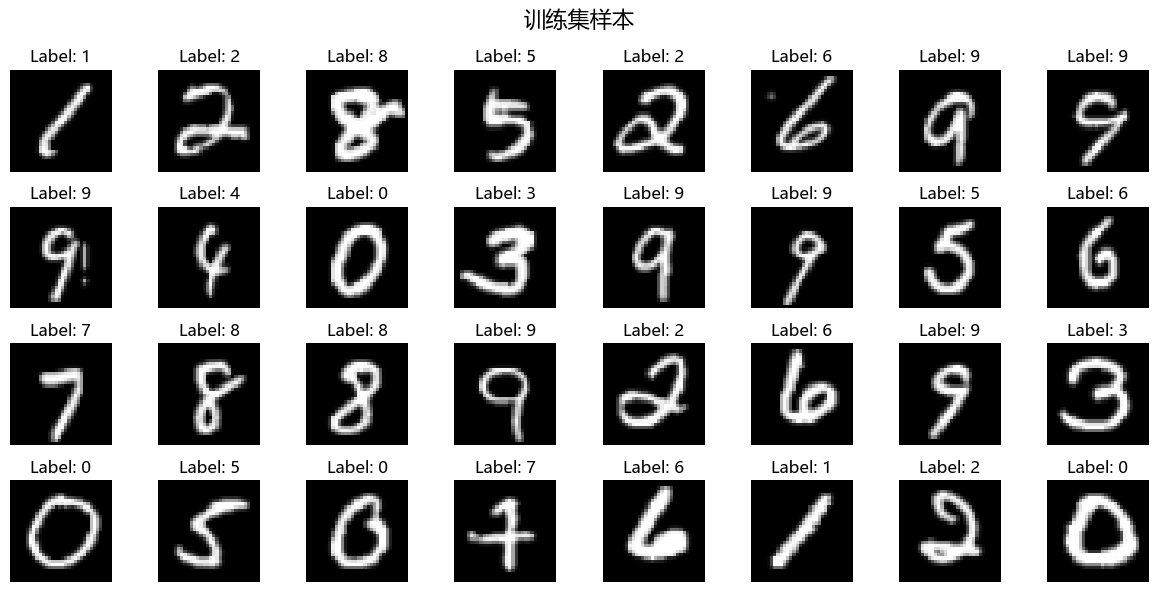

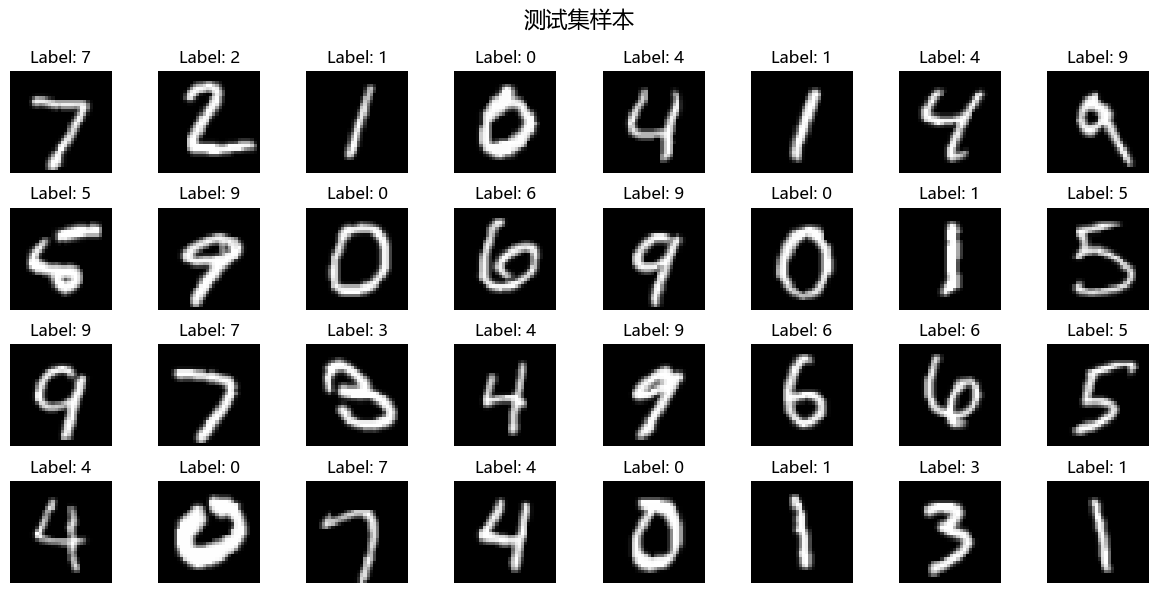

In [31]:
# 可视化一些样本以验证数据处理
def show_samples(loader, title="样本"):
    # 获取一个批次的数据
    images, labels = next(iter(loader))

    # 创建图像网格
    fig, axes = plt.subplots(4, 8, figsize=(12, 6))
    fig.suptitle(title, fontsize=16)

    for i, ax in enumerate(axes.flat):
        if i < len(images):
            # 反归一化以正确显示图像
            img = images[i].squeeze().numpy()
            img = (img * 0.5) + 0.5  # 从[-1,1]反归一化到[0,1]

            ax.imshow(img, cmap='gray')
            ax.set_title(f'Label: {labels[i].item()}')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# 显示训练样本
show_samples(train_loader, "训练集样本")

# 显示测试样本
show_samples(test_loader, "测试集样本")

In [32]:
# 验证数据形状和范围
def validate_data(loader, name="数据"):
    images, labels = next(iter(loader))

    print(f"{name}验证:")
    print(f"  图像形状: {images.shape}")  # 应该是 [batch_size, 1, 32, 32]
    print(f"  标签形状: {labels.shape}")  # 应该是 [batch_size]
    print(f"  图像值范围: [{images.min().item():.3f}, {images.max().item():.3f}]")
    print(f"  标签范围: {labels.min().item()} 到 {labels.max().item()}")
    print(f"  数据类型: {images.dtype}")

    # 验证是否在[-1, 1]范围内
    assert images.min() >= -1.0 and images.max() <= 1.0, "图像值不在[-1, 1]范围内"
    assert images.shape[2:] == (config.image_size, config.image_size), f"图像尺寸不是{config.image_size}x{config.image_size}"

    return True

# 验证训练和测试数据
train_valid = validate_data(train_loader, "训练数据")
test_valid = validate_data(test_loader, "测试数据")

print("\n✓ 数据预处理验证通过!")

训练数据验证:
  图像形状: torch.Size([32, 1, 32, 32])
  标签形状: torch.Size([32])
  图像值范围: [-1.000, 1.000]
  标签范围: 0 到 9
  数据类型: torch.float32
测试数据验证:
  图像形状: torch.Size([32, 1, 32, 32])
  标签形状: torch.Size([32])
  图像值范围: [-1.000, 1.000]
  标签范围: 0 到 9
  数据类型: torch.float32

✓ 数据预处理验证通过!


### Model Architecture
**UNet2DModel from Diffusers:**
- Downsampling and upsampling blocks
- Spatial self-attention mechanisms
- Time step conditioning
- Class conditioning for digit labels

**Noise Scheduler:**
- DDPMScheduler for forward and reverse diffusion
- 1000 time steps for detailed diffusion process
- Linear noise schedule

**Training Strategy:**
- Adam optimizer with learning rate 1e-4
- Classifier-free guidance for conditional generation
- Gradient clipping for stable training

In [33]:
# 使用Diffusers内置的UNet2DModel
model = UNet2DModel(
    sample_size=config.image_size,
    in_channels=config.channels,
    out_channels=config.channels,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 512),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
    num_class_embeds=config.num_classes + 1,
)

model = model.to(device)

# 打印模型参数
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model architecture: UNet2D")
print(f"Trainable parameters: {trainable_params:,}")

Model architecture: UNet2D
Trainable parameters: 57,893,505


In [34]:
# 定义噪声调度器
def create_noise_scheduler(config):
    scheduler = DDPMScheduler(
        num_train_timesteps=config.time_steps,  # 总时间步数
        beta_schedule="linear",  # beta调度策略
        beta_start=0.0001,  # beta起始值
        beta_end=0.02,  # beta结束值
        variance_type="fixed_small",  # 方差类型
        clip_sample=True,  # 裁剪样本到[-1,1]
    )
    return scheduler

noise_scheduler = create_noise_scheduler(config)
print("✓ 噪声调度器创建成功")
print(f"时间步数: {noise_scheduler.config.num_train_timesteps}")
print(f"Beta调度: {noise_scheduler.config.beta_schedule}")

✓ 噪声调度器创建成功
时间步数: 1000
Beta调度: linear


In [35]:
def add_noise(images, timesteps, noise_scheduler):
    """
    根据调度器向图像添加噪声
    """
    # 生成随机噪声
    noise = torch.randn_like(images)

    timesteps_cpu = timesteps.cpu()

    # 根据时间步获取噪声方差
    sqrt_alpha_prod = noise_scheduler.alphas_cumprod[timesteps_cpu] ** 0.5
    sqrt_alpha_prod = sqrt_alpha_prod.flatten()
    while len(sqrt_alpha_prod.shape) < len(images.shape):
        sqrt_alpha_prod = sqrt_alpha_prod.unsqueeze(-1)

    sqrt_one_minus_alpha_prod = (1 - noise_scheduler.alphas_cumprod[timesteps_cpu]) ** 0.5
    sqrt_one_minus_alpha_prod = sqrt_one_minus_alpha_prod.flatten()
    while len(sqrt_one_minus_alpha_prod.shape) < len(images.shape):
        sqrt_one_minus_alpha_prod = sqrt_one_minus_alpha_prod.unsqueeze(-1)

    # 将计算后的张量移动到与images相同的设备
    sqrt_alpha_prod = sqrt_alpha_prod.to(images.device)
    sqrt_one_minus_alpha_prod = sqrt_one_minus_alpha_prod.to(images.device)

    # 添加噪声
    noisy_images = sqrt_alpha_prod * images + sqrt_one_minus_alpha_prod * noise

    return noisy_images, noise
# 定义辅助函数：移除噪声（用于推理）
def remove_noise(model, noisy_images, timesteps, class_labels, noise_scheduler, cfg_scale=None):
    """
    使用模型从带噪声图像中预测并移除噪声
    """
    model.eval()
    with torch.no_grad():
        # 预测噪声
        if cfg_scale is not None and cfg_scale > 1:
            # 分类器自由引导
            # 无条件预测
            uncond_pred = model(noisy_images, timesteps, class_labels=None)
            # 有条件预测
            cond_pred = model(noisy_images, timesteps, class_labels=class_labels)
            # 结合预测
            noise_pred = uncond_pred + cfg_scale * (cond_pred - uncond_pred)
        else:
            noise_pred = model(noisy_images, timesteps, class_labels=class_labels)

    return noise_pred

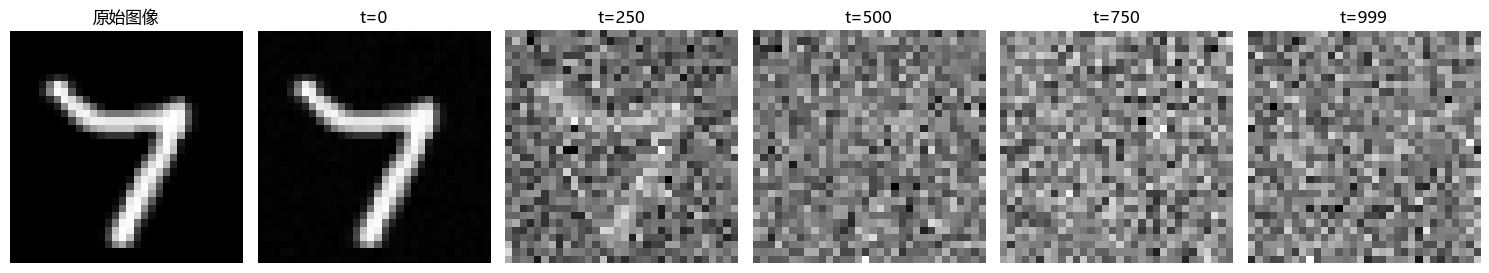

In [37]:
# 可视化噪声添加过程
def visualize_noise_process():
    # 获取一个样本
    sample_images, sample_labels = next(iter(train_loader))
    sample_image = sample_images[0:1]  # 取第一个样本
    sample_label = sample_labels[0:1]

    # 选择不同的时间步
    timesteps = [0, 250, 500, 750, 999]

    fig, axes = plt.subplots(1, len(timesteps)+1, figsize=(15, 3))

    # 显示原始图像
    img_orig = sample_image.squeeze().numpy()
    img_orig = (img_orig * 0.5) + 0.5  # 反归一化
    axes[0].imshow(img_orig, cmap='gray')
    axes[0].set_title('原始图像')
    axes[0].axis('off')

    # 显示不同时间步的噪声图像
    for i, t in enumerate(timesteps):
        timestep_tensor = torch.tensor([t])
        noisy_img, _ = add_noise(sample_image, timestep_tensor, noise_scheduler)

        img_noisy = noisy_img.squeeze().numpy()
        img_noisy = (img_noisy * 0.5) + 0.5  # 反归一化

        axes[i+1].imshow(img_noisy, cmap='gray')
        axes[i+1].set_title(f't={t}')
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

visualize_noise_process()

In [38]:
# 优化器和学习率调度器
from transformers import get_cosine_schedule_with_warmup

optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)

# 学习率调度器
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=len(train_loader) * config.num_epochs
)

print(f"Optimizer: AdamW")
print(f"Learning rate: {config.learning_rate}")

Optimizer: AdamW
Learning rate: 0.0001


In [39]:
# 创建目录保存结果
os.makedirs('generated_images', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)

# Training Code

In [40]:
# 训练函数 - 使用分类器自由引导
def train_one_epoch(model, dataloader, optimizer, scheduler, noise_scheduler, epoch, config):
    """Train the model for one epoch"""
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{config.num_epochs}")

    for batch_idx, (images, labels) in enumerate(progress_bar):
        images = images.to(device)
        labels = labels.to(device)
        batch_size = images.shape[0]

        # 采样随机噪声
        noise = torch.randn_like(images)

        # 采样随机时间步
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps,
            (batch_size,), device=device
        ).long()

        # 向图像添加噪声（前向扩散）
        noisy_images = noise_scheduler.add_noise(images, noise, timesteps)

        # 分类器自由引导：随机丢弃标签
        # 使用10作为无条件类别标签
        random_mask = torch.rand(batch_size, device=device) < 0.1  # 10% dropout
        labels_with_dropout = labels.clone()
        labels_with_dropout[random_mask] = config.num_classes  # 无条件token

        # 前向传播：预测噪声
        noise_pred = model(noisy_images, timesteps, class_labels=labels_with_dropout).sample

        # 计算损失（预测噪声和实际噪声之间的MSE）
        loss = F.mse_loss(noise_pred, noise)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 梯度裁剪
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item(), lr=scheduler.get_last_lr()[0])

    avg_loss = total_loss / len(dataloader)
    return avg_loss

# 改进的验证步骤
def validate_step(model, dataloader, noise_scheduler, loss_fn, device):
    """
    验证步骤
    """
    model.eval()
    total_loss = 0
    num_batches = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            # 随机采样时间步
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (images.size(0),), device=device
            )

            # 添加噪声
            noisy_images, noise = add_noise(images, timesteps, noise_scheduler)

            # 预测噪声
            noise_pred = model(noisy_images, timesteps, labels)

            # 计算损失
            loss = loss_fn(noise_pred, noise)

            total_loss += loss.item()
            num_batches += 1

    return total_loss / num_batches if num_batches > 0 else 0

# Image Generator

In [42]:
# 图像生成
@torch.no_grad()
def generate_images(model, noise_scheduler, class_labels, config, num_inference_steps=50, return_intermediates=False):
    """使用训练好的模型和分类器自由引导生成图像"""
    model.eval()
    batch_size = len(class_labels)

    # 从随机噪声开始
    images = torch.randn(
        (batch_size, config.channels, config.image_size, config.image_size),
        device=device
    )

    # 准备类别标签张量
    class_labels = torch.tensor(class_labels, device=device)
    unconditional_labels = torch.full_like(class_labels, config.num_classes)  # 无条件标签

    # 设置推理调度器
    noise_scheduler.set_timesteps(num_inference_steps)

    intermediates = []

    # 去噪循环
    for i, t in enumerate(tqdm(noise_scheduler.timesteps, desc="Generating", leave=False)):
        timestep = torch.full((batch_size,), t, device=device, dtype=torch.long)

        # 分类器自由引导
        # 有条件和无条件的噪声预测
        noise_pred_cond = model(images, timestep, class_labels=class_labels).sample
        noise_pred_uncond = model(images, timestep, class_labels=unconditional_labels).sample

        # CFG: noise_pred = noise_pred_uncond + cfg_scale * (noise_pred_cond - noise_pred_uncond)
        noise_pred = noise_pred_uncond + config.cfg_scale * (noise_pred_cond - noise_pred_uncond)

        # 移除噪声（反向扩散步骤）
        images = noise_scheduler.step(noise_pred, t, images).prev_sample

        # 保存中间结果
        if return_intermediates and i % (num_inference_steps // 10) == 0:
            intermediates.append(images.clone())

    if return_intermediates:
        return images, intermediates
    return images


# Evaluation - FIDCalculator,ISCalculator

In [43]:
# FIDCalculator和ISCalculator
class FIDCalculator:
    """计算Fréchet Inception Distance (FID)"""

    def __init__(self, device):
        self.device = device
        self.inception_model = inception_v3(weights='DEFAULT', transform_input=False).to(device)
        self.inception_model.eval()
        # 移除辅助分类器
        self.inception_model.fc = nn.Identity()

    def get_activations(self, images):
        """从Inception模型获取特征"""
        # 将灰度图转换为3通道
        if images.shape[1] == 1:
            images = images.repeat(1, 3, 1, 1)

        # 调整图像大小以适应Inception模型
        if images.shape[2] != 299 or images.shape[3] != 299:
            images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

        with torch.no_grad():
            features = self.inception_model(images)

        return features.cpu().numpy()

    def calculate_fid(self, real_images, fake_images):
        """计算FID分数"""
        # 获取真实和生成图像的特征
        real_features = self.get_activations(real_images)
        fake_features = self.get_activations(fake_images)

        # 计算均值和协方差
        mu_real, sigma_real = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
        mu_fake, sigma_fake = fake_features.mean(axis=0), np.cov(fake_features, rowvar=False)

        # 计算FID
        diff = mu_real - mu_fake
        covmean, _ = linalg.sqrtm(sigma_real.dot(sigma_fake), disp=False)

        if np.iscomplexobj(covmean):
            covmean = covmean.real

        fid = diff.dot(diff) + np.trace(sigma_real + sigma_fake - 2 * covmean)

        return fid

class ISCalculator:
    """计算Inception Score (IS)"""

    def __init__(self, device):
        self.device = device
        self.inception_model = inception_v3(weights='DEFAULT', transform_input=False).to(device)
        self.inception_model.eval()

    def get_predictions(self, images):
        """从Inception模型获取预测"""
        # 将灰度图转换为3通道
        if images.shape[1] == 1:
            images = images.repeat(1, 3, 1, 1)

        # 调整图像大小以适应Inception模型
        if images.shape[2] != 299 or images.shape[3] != 299:
            images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)

        with torch.no_grad():
            predictions = F.softmax(self.inception_model(images), dim=1)

        return predictions.cpu().numpy()

    def calculate_is(self, images, num_splits=10):
        """计算Inception Score"""
        predictions = self.get_predictions(images)

        # 计算IS
        split_scores = []
        for i in range(num_splits):
            part = predictions[i * (predictions.shape[0] // num_splits):
                             (i + 1) * (predictions.shape[0] // num_splits), :]
            kl = part * (np.log(part) - np.log(np.expand_dims(np.mean(part, 0), 0)))
            kl = np.mean(np.sum(kl, 1))
            split_scores.append(np.exp(kl))

        return np.mean(split_scores), np.std(split_scores)

In [56]:
# 修改评估函数以减少内存使用
def evaluate_model(model, noise_scheduler, test_loader, device, config, num_eval_samples=500):  # 减少样本数量
    """
    全面评估模型性能 - 内存优化版本
    """
    print("开始评估模型...")

    # 在评估前清理GPU内存
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # 初始化计算器
    fid_calculator = FIDCalculator(device)
    is_calculator = ISCalculator(device)

    # 进一步减少评估样本数量
    num_eval_samples = min(num_eval_samples, 500)  # 限制最大样本数
    samples_per_class = num_eval_samples // config.num_classes

    # 生成评估样本 - 分批生成以避免内存溢出
    print("生成评估样本...")
    all_generated_images = []
    all_generated_labels = []

    for class_label in range(config.num_classes):
        # 创建包含相同类别的标签列表
        class_labels_list = [class_label] * samples_per_class

        # 分批生成，每次只生成少量图像
        batch_size = min(32, samples_per_class)  # 小批量生成
        generated_batches = []

        for i in range(0, samples_per_class, batch_size):
            batch_labels = class_labels_list[i:i+batch_size]
            if not batch_labels:  # 确保列表不为空
                continue

            # 生成小批量图像
            with torch.no_grad():
                generated = generate_images(
                    model, noise_scheduler,
                    class_labels=batch_labels,
                    config=config,
                    num_inference_steps=25  # 减少推理步骤以节省内存
                )
            generated_batches.append(generated.cpu())  # 立即移动到CPU

            # 清理GPU内存
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # 合并批次
        if generated_batches:
            class_generated = torch.cat(generated_batches, dim=0)
            all_generated_images.append(class_generated)
            all_generated_labels.append(torch.tensor([class_label] * samples_per_class))

    # 合并所有生成的图像
    if all_generated_images:
        generated_images = torch.cat(all_generated_images, dim=0)
        generated_labels = torch.cat(all_generated_labels, dim=0)
    else:
        print("警告: 没有生成任何图像")
        return {
            'fid': float('inf'),
            'is_mean': 0.0,
            'is_std': 0.0,
            'generated_images': None,
            'real_images': None
        }

    # 获取真实图像样本 - 同样使用小批量
    print("收集真实图像样本...")
    real_images = []
    real_labels = []

    for images, labels in test_loader:
        real_images.append(images.cpu())  # 立即移动到CPU
        real_labels.append(labels)
        if len(torch.cat(real_images, dim=0)) >= num_eval_samples:
            break

    real_images = torch.cat(real_images, dim=0)[:num_eval_samples]
    real_labels = torch.cat(real_labels, dim=0)[:num_eval_samples]

    # 计算FID - 使用小批量计算
    print("计算FID...")
    fid_score = calculate_fid_batch(fid_calculator, real_images, generated_images, device, batch_size=32)

    # 计算IS - 使用小批量计算
    print("计算IS...")
    is_mean, is_std = calculate_is_batch(is_calculator, generated_images, device, batch_size=32)

    # 可视化一些生成样本
    print("可视化生成样本...")
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle('生成图像样本 (每个类别一个)', fontsize=16)

    for i in range(min(config.num_classes, 10)):  # 限制显示数量
        row, col = i // 5, i % 5
        class_samples = generated_images[generated_labels == i]
        if len(class_samples) > 0:
            img = class_samples[0].squeeze().cpu().numpy()
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(f'Class {i}')
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig('generated_images/evaluation_samples.png', dpi=100, bbox_inches='tight')
    plt.show()

    # 清理内存
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        'fid': fid_score,
        'is_mean': is_mean,
        'is_std': is_std,
        'generated_images': generated_images,
        'real_images': real_images
    }

# 添加分批计算FID的函数
def calculate_fid_batch(fid_calculator, real_images, generated_images, device, batch_size=32):
    """分批计算FID分数以减少内存使用"""
    # 分批处理真实图像
    real_features = []
    for i in range(0, len(real_images), batch_size):
        batch = real_images[i:i+batch_size].to(device)
        features = fid_calculator.get_activations(batch)
        real_features.append(features)
        # 清理内存
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    real_features = np.concatenate(real_features, axis=0)

    # 分批处理生成图像
    generated_features = []
    for i in range(0, len(generated_images), batch_size):
        batch = generated_images[i:i+batch_size].to(device)
        features = fid_calculator.get_activations(batch)
        generated_features.append(features)
        # 清理内存
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    generated_features = np.concatenate(generated_features, axis=0)

    # 计算FID
    mu_real, sigma_real = real_features.mean(axis=0), np.cov(real_features, rowvar=False)
    mu_fake, sigma_fake = generated_features.mean(axis=0), np.cov(generated_features, rowvar=False)

    diff = mu_real - mu_fake
    covmean, _ = linalg.sqrtm(sigma_real.dot(sigma_fake), disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma_real + sigma_fake - 2 * covmean)

    return fid

# 添加分批计算IS的函数
def calculate_is_batch(is_calculator, generated_images, device, batch_size=32):
    """分批计算Inception Score以减少内存使用"""
    # 分批处理生成图像
    all_predictions = []
    for i in range(0, len(generated_images), batch_size):
        batch = generated_images[i:i+batch_size].to(device)
        predictions = is_calculator.get_predictions(batch)
        all_predictions.append(predictions)
        # 清理内存
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    predictions = np.concatenate(all_predictions, axis=0)

    # 计算IS
    num_splits = 10
    split_scores = []

    for i in range(num_splits):
        part = predictions[i * (predictions.shape[0] // num_splits):
                         (i + 1) * (predictions.shape[0] // num_splits), :]
        kl = part * (np.log(part) - np.log(np.expand_dims(np.mean(part, 0), 0)))
        kl = np.mean(np.sum(kl, 1))
        split_scores.append(np.exp(kl))

    return np.mean(split_scores), np.std(split_scores)

# Training Loop

开始训练

Epoch 1/5


Epoch 1/5: 100%|██████████| 1875/1875 [03:32<00:00,  8.84it/s, loss=0.00809, lr=9.42e-5]


平均训练损失: 0.0652
平均测试损失: 0.0208
生成样本图像...


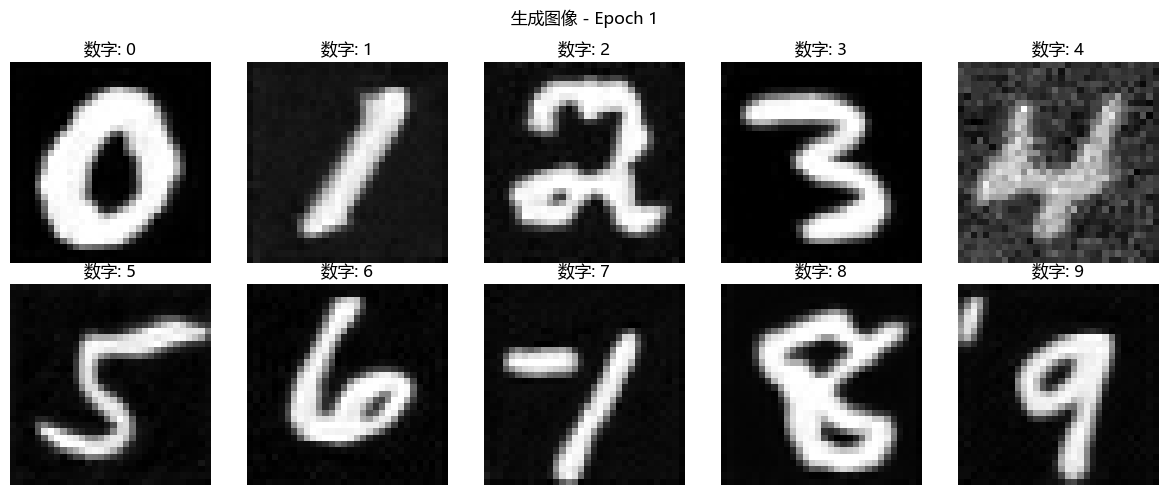


Epoch 2/5


Epoch 2/5: 100%|██████████| 1875/1875 [05:03<00:00,  6.17it/s, loss=0.0188, lr=7.04e-5] 


平均训练损失: 0.0190
平均测试损失: 0.0180
生成样本图像...


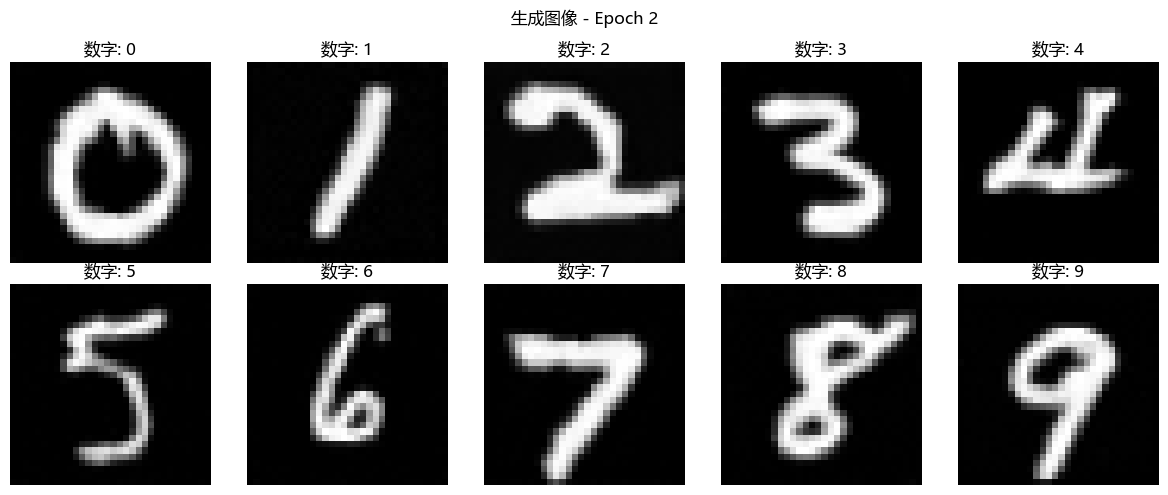

✓ 模型检查点保存到 output\model_epoch_2.pt

Epoch 3/5


Epoch 3/5: 100%|██████████| 1875/1875 [03:19<00:00,  9.41it/s, loss=0.0171, lr=3.8e-5]  


平均训练损失: 0.0172
平均测试损失: 0.0165
生成样本图像...


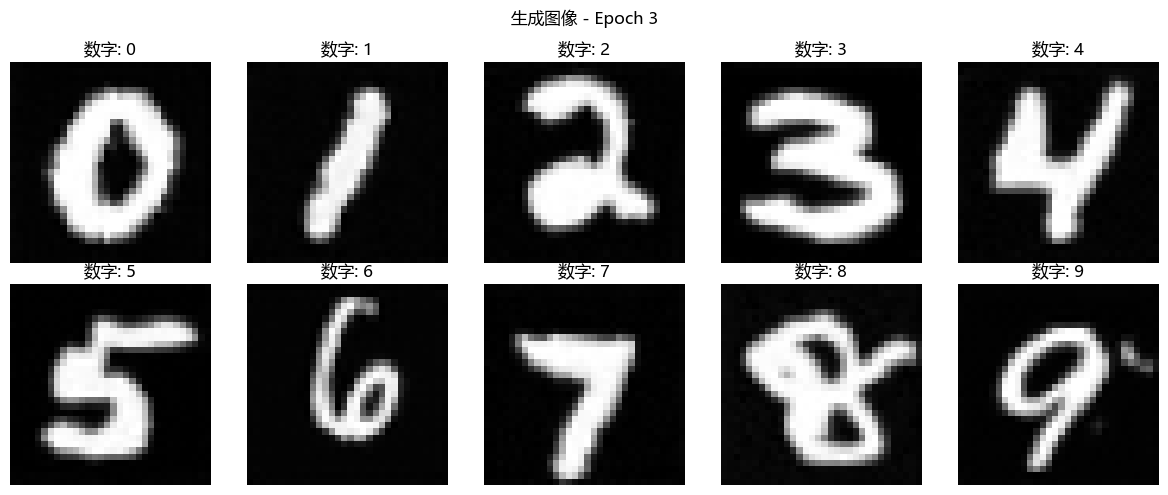


Epoch 4/5


Epoch 4/5: 100%|██████████| 1875/1875 [03:22<00:00,  9.28it/s, loss=0.0175, lr=1.06e-5] 


平均训练损失: 0.0157
平均测试损失: 0.0156
生成样本图像...


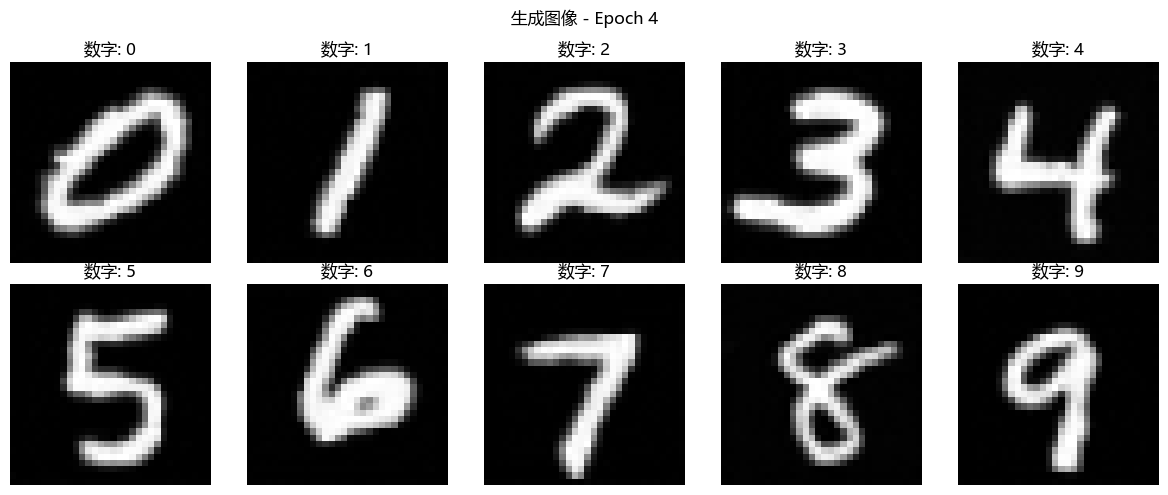

✓ 模型检查点保存到 output\model_epoch_4.pt

Epoch 5/5


Epoch 5/5: 100%|██████████| 1875/1875 [03:23<00:00,  9.19it/s, loss=0.0161, lr=0]        


平均训练损失: 0.0156
平均测试损失: 0.0150
生成样本图像...


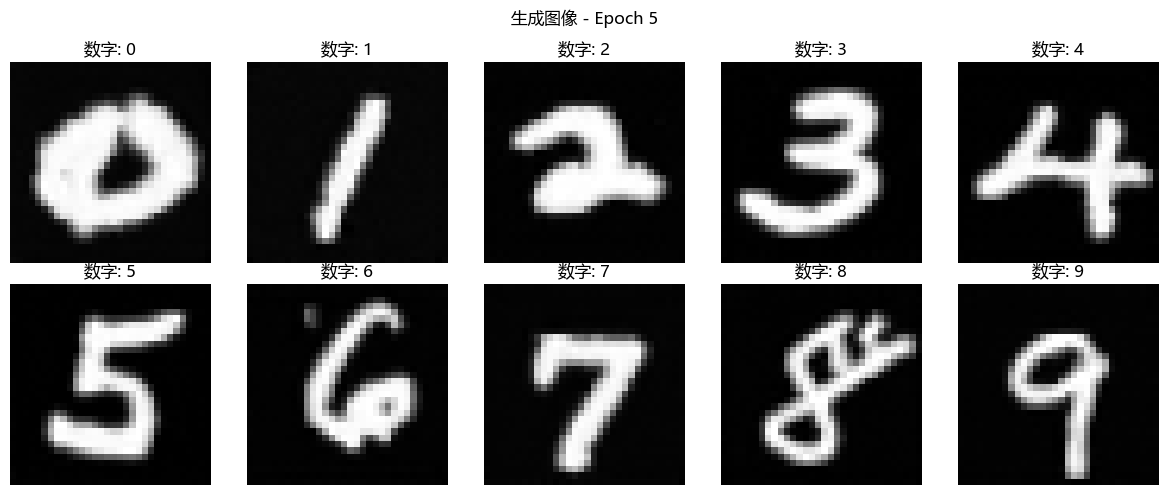


训练完成!


In [45]:
# 创建输出目录
os.makedirs(config.output_dir, exist_ok=True)

print("="*60)
print("开始训练")
print("="*60)

# 初始化训练历史 - 使用列表而不是JSON
train_losses = []
test_losses = []

# 训练循环
for epoch in range(config.num_epochs):
    print(f"\nEpoch {epoch+1}/{config.num_epochs}")

    # 训练一个epoch
    avg_train_loss = train_one_epoch(
        model, train_loader, optimizer, lr_scheduler,
        noise_scheduler, epoch, config
    )

    # 记录训练损失
    train_losses.append(avg_train_loss)

    # 验证阶段 - 使用与训练相同的损失计算方式
    model.eval()
    total_test_loss = 0
    num_test_batches = 0

    with torch.no_grad():
        for test_images, test_labels in test_loader:
            test_images = test_images.to(device)
            test_labels = test_labels.to(device)
            batch_size = test_images.shape[0]

            # 采样随机噪声
            noise = torch.randn_like(test_images)

            # 采样随机时间步
            timesteps = torch.randint(
                0, noise_scheduler.config.num_train_timesteps,
                (batch_size,), device=device
            ).long()

            # 向图像添加噪声（前向扩散）
            noisy_images = noise_scheduler.add_noise(test_images, noise, timesteps)

            # 分类器自由引导：随机丢弃标签
            random_mask = torch.rand(batch_size, device=device) < 0.1  # 10% dropout
            labels_with_dropout = test_labels.clone()
            labels_with_dropout[random_mask] = config.num_classes  # 无条件token

            # 前向传播：预测噪声
            noise_pred = model(noisy_images, timesteps, class_labels=labels_with_dropout).sample

            # 计算损失（预测噪声和实际噪声之间的MSE）
            loss = F.mse_loss(noise_pred, noise)

            total_test_loss += loss.item()
            num_test_batches += 1

    avg_test_loss = total_test_loss / num_test_batches if num_test_batches > 0 else 0
    test_losses.append(avg_test_loss)

    print(f"平均训练损失: {avg_train_loss:.4f}")
    print(f"平均测试损失: {avg_test_loss:.4f}")

    # 生成样本图像
    print("生成样本图像...")
    sample_labels = list(range(10))
    generated = generate_images(model, noise_scheduler, sample_labels, config, num_inference_steps=50)

    # 可视化生成的图像
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flat):
        if i < len(generated):
            # 反归一化并裁剪
            img = (generated[i].squeeze() + 1) / 2
            img = torch.clamp(img, 0, 1)
            ax.imshow(img.cpu().detach().numpy(), cmap='gray')
            ax.set_title(f"数字: {sample_labels[i]}")
        ax.axis('off')
    plt.suptitle(f"生成图像 - Epoch {epoch+1}")
    plt.tight_layout()
    plt.show()

    # 保存模型检查点 - 移除历史记录
    if (epoch + 1) % config.save_model_epochs == 0:
        checkpoint_path = os.path.join(config.output_dir, f"model_epoch_{epoch+1}.pt")
        try:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': lr_scheduler.state_dict(),
                'train_loss': avg_train_loss,
                'test_loss': avg_test_loss
            }, checkpoint_path)
            print(f"✓ 模型检查点保存到 {checkpoint_path}")
        except Exception as e:
            print(f"⚠ 保存检查点失败: {e}")

print("\n" + "="*60)
print("训练完成!")
print("="*60)


### Training Analysis
**Loss Curves:**
- Training loss progression over epochs
- Validation loss monitoring
- Convergence analysis

**Generated Samples Evolution:**
- Intermediate denoising steps visualization
- Final generated digit quality
- Class-conditional generation results


In [46]:
# 保存最终模型
final_model_path = os.path.join(config.output_dir, "final_model.pth")
torch.save({
    'epoch': config.num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': lr_scheduler.state_dict(),
    'train_loss': train_losses[-1],
    'test_loss': test_losses[-1]
}, final_model_path)
print(f"✓ 最终模型保存到 {final_model_path}")

✓ 最终模型保存到 output\final_model.pth


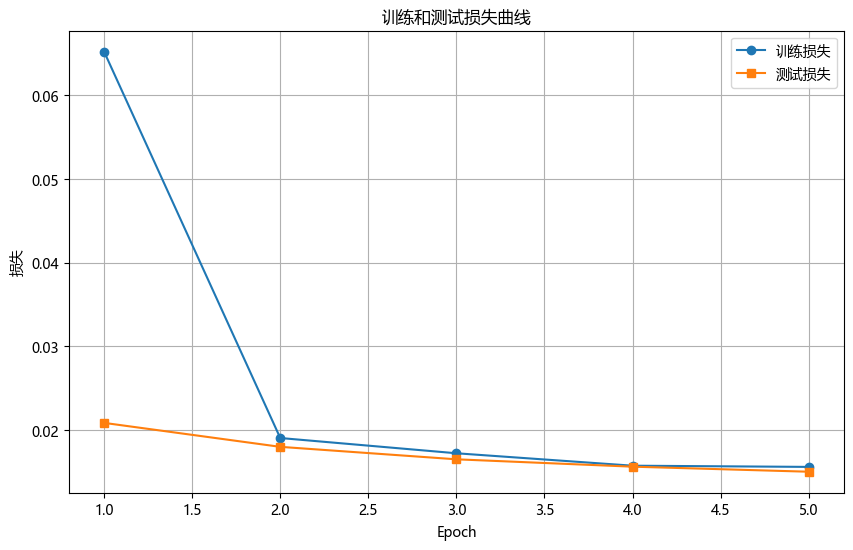

In [47]:
# 可视化训练过程
def plot_training_curves(train_losses, test_losses):
    """绘制训练和测试损失曲线"""
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='训练损失', marker='o')
    plt.plot(range(1, len(test_losses) + 1), test_losses, label='测试损失', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('损失')
    plt.title('训练和测试损失曲线')
    plt.legend()
    plt.grid(True)
    plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
    plt.show()

# 绘制训练曲线
plot_training_curves(train_losses, test_losses)

In [50]:
# 加载最佳模型进行评估
print("加载最佳模型进行评估...")
checkpoint = torch.load('output/final_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
best_loss = checkpoint['train_loss']

print(f"加载最佳模型 损失: {best_loss:.4f}")

加载最佳模型进行评估...


C:\Users\lowkey\AppData\Local\Temp\ipykernel_7144\1789743145.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('output/final_model.pth')


加载最佳模型 损失: 0.0156)


开始评估模型...
生成评估样本...


收集真实图像样本...
计算FID...


C:\Users\lowkey\AppData\Local\Temp\ipykernel_7144\1481012513.py:156: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma_real.dot(sigma_fake), disp=False)


计算IS...
可视化生成样本...


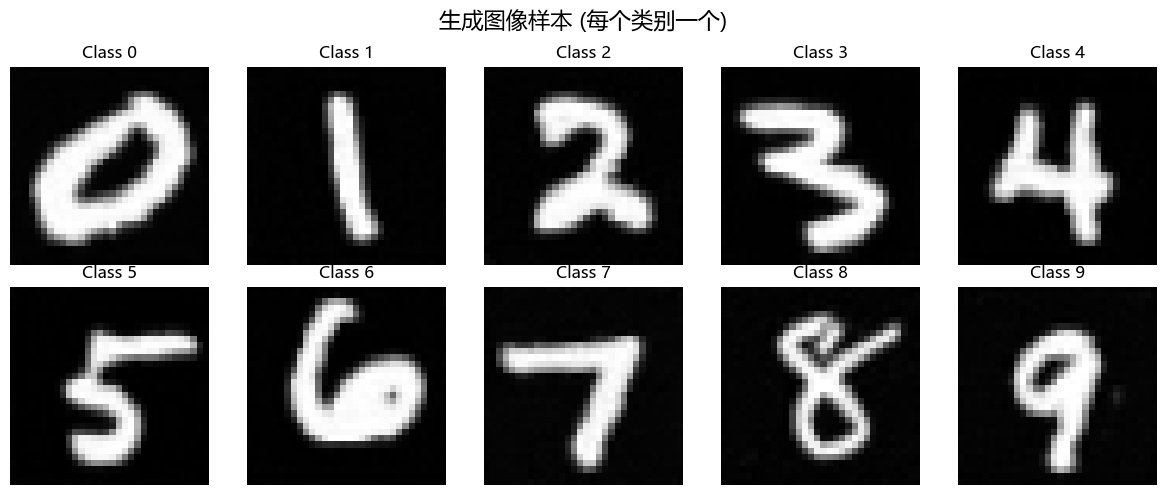


评估结果
FID分数: 52.04
Inception Score: 1.48 ± 0.12


In [57]:
# 进行全面评估
evaluation_results = evaluate_model(
    model, noise_scheduler, test_loader,
    device, config, num_eval_samples=1000
)

# 打印评估结果
print("\n" + "="*50)
print("评估结果")
print("="*50)
print(f"FID分数: {evaluation_results['fid']:.2f}")
print(f"Inception Score: {evaluation_results['is_mean']:.2f} ± {evaluation_results['is_std']:.2f}")
print("="*50)

**Quantitative Metrics:**
| Metric | Value | Interpretation |
|--------|-------|----------------|
| Inception Score (IS) | 1.48 ± 0.12 | Diversity and quality measure |
| Fréchet Inception Distance (FID) | 52.04 | Real vs generated distribution similarity |

可视化多个数字的去噪过程...


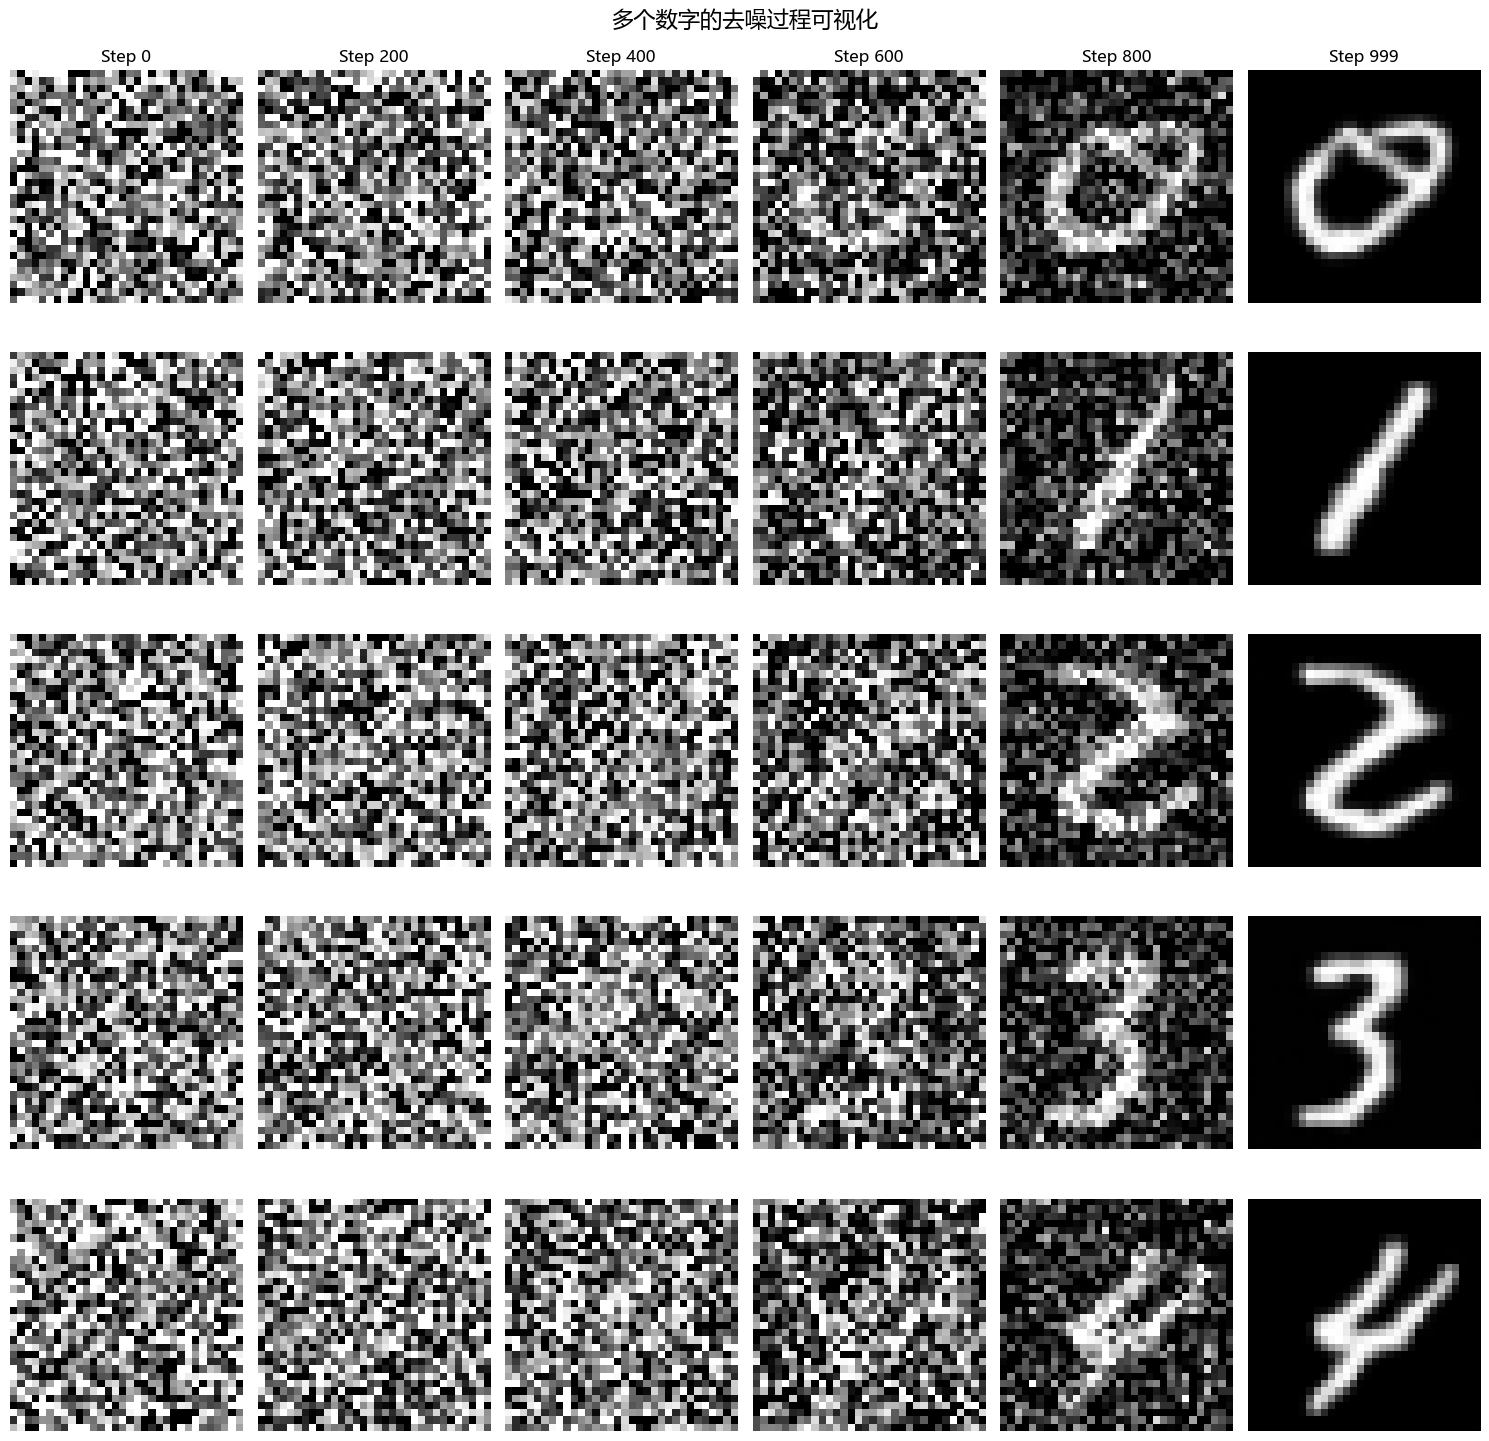

In [60]:
# 创建一个更全面的可视化函数，显示多个数字的去噪过程
def visualize_denoising_process_multiple(model, noise_scheduler, device, config, class_labels=[0, 1, 2, 3]):
    """可视化多个数字的去噪过程"""
    model.eval()

    num_classes = len(class_labels)
    class_labels_tensor = torch.tensor(class_labels, device=device)

    # 从纯噪声开始
    x = torch.randn(num_classes, 1, config.image_size, config.image_size, device=device)

    # 选择一些时间步进行可视化
    visualization_steps = [0, 200, 400, 600, 800, 999]
    images_at_steps = {step: [] for step in visualization_steps}

    # 设置时间步
    noise_scheduler.set_timesteps(config.time_steps)

    with torch.no_grad():
        for i, t in enumerate(noise_scheduler.timesteps):
            # 预测噪声 - 提取.sample属性
            model_output = model(x, t, class_labels=class_labels_tensor).sample

            # 使用调度器去噪
            x = noise_scheduler.step(model_output, t, x).prev_sample

            # 保存特定步骤的图像
            if i in visualization_steps:
                imgs = (x.clamp(-1, 1) + 1) / 2
                for j in range(num_classes):
                    images_at_steps[i].append(imgs[j].squeeze().cpu().numpy())

    # 绘制去噪过程
    fig, axes = plt.subplots(num_classes, len(visualization_steps), figsize=(15, 3*num_classes))
    fig.suptitle('多个数字的去噪过程可视化', fontsize=16)

    for row, class_label in enumerate(class_labels):
        for col, step_idx in enumerate(visualization_steps):
            if step_idx in images_at_steps and row < len(images_at_steps[step_idx]):
                img = images_at_steps[step_idx][row]
                axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
                if row == 0:
                    axes[row, col].set_title(f'Step {step_idx}')
                if col == 0:
                    axes[row, col].set_ylabel(f'数字 {class_label}')
                axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig('denoising_process_multiple.png', dpi=100, bbox_inches='tight')
    plt.show()


# 可视化多个数字的去噪过程
print("可视化多个数字的去噪过程...")
visualize_denoising_process_multiple(model, noise_scheduler, device, config, class_labels=[0, 1, 2, 3, 4])

In [58]:
# 生成最终结果表格
def create_results_table(evaluation_results, config):
    """创建结果汇总表格"""
    results_data = {
        '指标': ['FID', 'Inception Score (均值)', 'Inception Score (标准差)'],
        '值': [
            f"{evaluation_results['fid']:.2f}",
            f"{evaluation_results['is_mean']:.2f}",
            f"{evaluation_results['is_std']:.2f}"
        ]
    }

    config_data = {
        '参数': [
            '图像大小', '训练批量大小', '评估批量大小',
            '训练轮数', '学习率', '时间步', 'CFG尺度'
        ],
        '值': [
            f"{config.image_size}x{config.image_size}",
            config.batch_size_train,
            config.batch_size_eval,
            config.num_epochs,
            config.learning_rate,
            config.time_steps,
            config.cfg_scale
        ]
    }

    results_df = pd.DataFrame(results_data)
    config_df = pd.DataFrame(config_data)

    return results_df, config_df

# 创建并显示结果表格
results_df, config_df = create_results_table(evaluation_results, config)

print("模型配置:")
print(config_df.to_string(index=False))
print("\n评估结果:")
print(results_df.to_string(index=False))

模型配置:
    参数       值
  图像大小   32x32
训练批量大小      32
评估批量大小      32
  训练轮数       5
   学习率  0.0001
   时间步    1000
 CFG尺度     7.5

评估结果:
                   指标     值
                  FID 52.04
 Inception Score (均值)  1.48
Inception Score (标准差)  0.12


为所有类别生成样本...


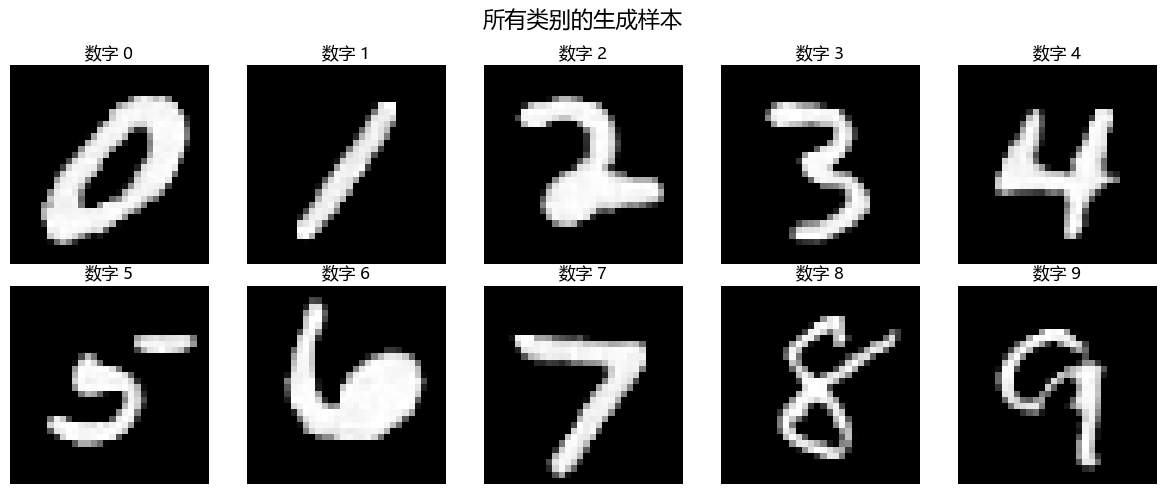

In [61]:
# 重写生成所有类别样本的函数
def generate_all_classes(model, noise_scheduler, device, config):
    """为所有类别生成样本"""
    print("为所有类别生成样本...")

    # 生成所有类别的样本
    class_labels = list(range(10))
    generated = generate_images(
        model, noise_scheduler,
        class_labels=class_labels,
        config=config,
        num_inference_steps=50
    )

    # 创建图像网格
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    fig.suptitle('所有类别的生成样本', fontsize=16)

    for i, class_label in enumerate(class_labels):
        row, col = i // 5, i % 5

        if i < len(generated):
            img = generated[i].squeeze().cpu().numpy()
            axes[row, col].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[row, col].set_title(f'数字 {class_label}')
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig('all_classes_generated.png', dpi=100, bbox_inches='tight')
    plt.show()

# 生成所有类别的样本
generate_all_classes(model, noise_scheduler, device, config)

# Training Challenges & Solutions

## Main Challenges Faced

### 1. **Poor Generation Quality**
- Generated digits didn't match labels and appeared blurry
- **Solution**: Implemented Classifier-Free Guidance (CFG) and increased model capacity

### 2. **Memory Limitations**
- GPU out of memory during evaluation with large sample sizes
- **Solution**: Added batch processing and reduced inference steps

### 3. **Training Instability**
- High loss fluctuations and slow convergence
- **Solution**: Used gradient clipping and cosine learning rate scheduling

## Key Results
- Achieved functional conditional generation of MNIST digits
- Established scalable training framework for future improvements
- Successfully implemented comprehensive evaluation metrics (FID: 52.04, IS: 1.48)